### Setting

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re

from pathlib import Path
BASE_DIR = Path().resolve().parent
DATA_DIR = "G:/我的云端硬盘/NLP_project"
model_dir = "G:/我的云端硬盘/NLP_project/health_models"

# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = Path("/content/drive/MyDrive/NLP_project")
# model_dir = Path("/content/drive/MyDrive/NLP_project/health_models")

def show_full(df):
    """
    Fully display a DataFrame without any truncation.
    Works for any df[...] slice.
    """
    import pandas as pd
    from IPython.display import display

    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None
    ):
        display(df)

In [3]:
import torch
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} as device.")

Using cpu as device.


### Load data

In [5]:
df_subchunks = pd.read_parquet(f"{DATA_DIR}/df_subchunks_raw.parquet")

In [6]:
DigiServ_chunks = (
    df_subchunks.loc[df_subchunks["industry"] == "Information & Digital Services",
                     ["chunk_uid", "url", "date", "title", "topic", "chunk_text"]]
    .copy()
    .rename(columns={"topic": "topic_v0"})
)
DigiServ_chunks.head(2)

,chunk_uid,url,date,title,topic_v0,chunk_text
3,4_0_0_0_0,https://thetaoofanarchy.substack.com/p/ai-feve...,2025-01-30,"""AI Fever!"" AI Is Animated Idiocy! Can This Hu...",13,"""AI Fever!"" AI Is Animated Idiocy! Can This Hu..."
4,4_0_0_0_1,https://thetaoofanarchy.substack.com/p/ai-feve...,2025-01-30,"""AI Fever!"" AI Is Animated Idiocy! Can This Hu...",13,These make believes have always been used as w...


In [7]:
print(len(DigiServ_chunks))

86530


### Bertopic

In [4]:
# ! pip install bertopic

In [26]:
### customize bertopic model
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

RANDOM_STATE = 27

# embedding_model = SentenceTransformer("thenlper/gte-small" , device="cuda")

umap_model = UMAP(
    n_neighbors=100,
    n_components=15,
    min_dist=0.2,
    metric="cosine",
    random_state=RANDOM_STATE
)

# 100,20
hdbscan_model = HDBSCAN(
    min_cluster_size=500,
    min_samples=100,
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5,                 # 关键：别太高，保住 gpt/openai/llm
    max_df=0.70,              # 砍掉跨站模板词，但不至于太猛
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]{3,}\b",
    # 你如果想加自定义 stopwords，见下方“可选增强”
)
ctfidf_model = ClassTfidfTransformer()

# All steps together
topic_model = BERTopic(
    # embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    nr_topics=20
)

In [12]:
docs = DigiServ_chunks["chunk_text"].tolist()

from sentence_transformers import SentenceTransformer
import numpy as np

embedding_model = SentenceTransformer(
    "thenlper/gte-small",
    device="cuda"
)

embeddings = embedding_model.encode(
    docs,
    batch_size=64,
    show_progress_bar=True
)

np.save(f"{DATA_DIR}/news_embeddings.npy", embeddings)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1353 [00:00<?, ?it/s]

In [27]:
import numpy as np

embeddings = np.load(f"{DATA_DIR}/news_embeddings.npy")

In [28]:
docs = DigiServ_chunks["chunk_text"].tolist()

topics, probs = topic_model.fit_transform(
    docs,
    embeddings
)

In [29]:
DigiServ_topics = topic_model.get_topic_info()
DigiServ_chunks_topics = DigiServ_chunks.assign( topic=topics,  probability=probs)

In [30]:
show_full(DigiServ_topics[["Topic", 'Representation',"Count"]])

,Topic,Representation,Count
0,-1,"[einstein, agentforce, salesforces, whales, reddits, benioff, cloudflare, crawlers, humanes, wearable device]",8365
1,0,"[clickup, hinton, contact center, rayban, recruiters, geoffrey hinton, claude code, claude sonnet, zuckerberg said, zooms]",15440
2,1,"[narendra, nigerias, indiaai, digi, continent, digi communications, narendra modi, communications announces, gitex, madras]",10296
3,2,"[chatgpt plus, nsfw, replika, companionship, characterai, parental, voice mode, italys, loneliness, advanced voice]",9968
4,3,"[databricks, forecast period, intelligence market, observability, software market, size forecast, service market, research report, market segmentation, vision market]",6165
5,4,"[clearview, security teams, attackers, threat detection, cisos, threat intelligence, department defense, firefighters, unmanned, security operations]",5438
6,5,"[brockman, shear, greg brockman, sutskever, openai board, openais board, murati, ilya, ouster, board members]",5006
7,6,"[voiceover, video creation, single prompt, engine built, visual style, video generator, training videos, creation process, voiceovers, video editing]",4526
8,7,"[bing search, googles search, searchgpt, edge browser, chatgpt atlas, perplexitys, bing chatbot, srinivas, microsofts bing, mehdi]",3646
9,8,"[deepseeks, ernie, baidus, qwen, alibaba cloud, chinese startup, startup deepseek, tongyi, chatbot ernie, liang]",2809


In [21]:
DigiServ_topics.to_csv(f"{DATA_DIR}/DigiServ_specific/DigiServ_topics.csv", index=False)
DigiServ_chunks_topics.to_parquet(f"{DATA_DIR}/DigiServ_specific/DigiServ_chunks_topics.parquet", index=False)

### Filter AI Chatbot/Integration Development and Competition

In [22]:
DigiServ_topics = pd.read_csv(f"{DATA_DIR}/DigiServ_specific/DigiServ_topics.csv")

In [60]:
manual_related_topics = [0,2,5,7,8,11,13,14,15]
df_ai_company = DigiServ_chunks_topics.loc[DigiServ_chunks_topics["topic"].isin(manual_related_topics)].copy()
df_ai_company['topic'].value_counts()

topic
0     15440
2      9968
5      5006
7      3646
8      2809
11     2251
13     1388
14     1325
15      963
Name: count, dtype: int64

### NER per Topic: Company and Technologies

In [61]:
sample_size = 1000

df_sample = (
    df_ai_company
    .groupby("topic", group_keys=False)
    .apply(lambda x: x.sample(frac=sample_size/len(df_ai_company), random_state=42))
)
df_sample['topic'].value_counts()

topic
0     361
2     233
5     117
7      85
8      66
11     53
13     32
14     31
15     23
Name: count, dtype: int64

In [69]:
df_sample.head(2)

,chunk_uid,url,date,title,topic_v0,chunk_text,topic,probability
2549,1771_0_0_0_2,https://www.forbes.com/sites/forbesbusinesscou...,2022-02-28,14 Strategies For Leveraging AI In Your Custom...,35,"By using AI, companies can collect key data po...",0,0.756537
114285,83021_0_0_0_1,https://telecom.economictimes.indiatimes.com/n...,2025-08-20,Meta AI Group: Meta restructures AI group agai...,18,"Before announcing MSL in June, the social medi...",0,1.000000


In [94]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [95]:
entity_system_msg = """\
You are an information extraction system for AI company news articles.

The user will provide a title and a text block from an article whose main topic is likely about AI companies, AI products, or frontier AI technologies.

Extract only explicitly mentioned entities from the following three categories:

1. ai_companies
2. ai_products
3. ai_technologies_and_capabilities


## ai_companies
Extract named companies, organizations, research labs, or startups that are part of the AI ecosystem.

Examples:
- OpenAI
- Anthropic
- Google
- DeepMind
- Microsoft
- Meta
- Nvidia
- Amazon
- Cohere
- Mistral
- xAI
- Hugging Face


## ai_products
Extract explicitly named AI products, model families, assistants, platforms, systems, or tools.

Examples:
- ChatGPT
- GPT-4
- GPT-4o
- Gemini
- Gemini 1.5
- Claude
- Claude 3
- DeepSeek
- DeepSeek-R1
- Copilot
- Midjourney
- DALL-E
- Sora
- Llama
- Grok


## ai_technologies_and_capabilities
Extract explicitly mentioned AI technologies, model types, technical approaches, or AI capabilities.

Examples:
- generative AI
- large language models
- multimodal AI
- reasoning
- coding assistance
- image generation
- video generation
- speech recognition
- fine-tuning
- inference
- AI chips
- model training
- retrieval-augmented generation
- reinforcement learning
- agentic AI


## Directions
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep names concise and canonical when possible.
- Preserve specific product names exactly when helpful.
- Classify company names under ai_companies.
- Classify named products, assistants, platforms, and model families under ai_products.
- Do not place a product name in ai_companies unless the text clearly uses it as an organization name.
- If a category has no valid entities, return an empty list for that category.
- Return valid JSON only.

## Category-specific exclusions

### For ai_companies
Do NOT extract generic or non-specific references such as:
- "the company"
- "the startup"
- "the firm"
- "the vendor"
- "the developer"
- "AI firms"
- "tech companies"
- "model makers"
- "researchers"
- "engineers"
- "developers"
- "the lab"
- "the organization"

Only extract a specific named company, organization, lab, or startup.

### For ai_products
Do NOT extract generic or non-specific references such as:
- "the model"
- "the chatbot"
- "the assistant"
- "the platform"
- "the tool"
- "the system"
- "the app"
- "the service"
- "an AI model"
- "an AI chatbot"
- "AI assistant"
- "AI tool"
- "language model"

Only extract a specific named product, assistant, platform, system, or model family.

### For ai_technologies_and_capabilities
Do NOT extract overly broad, vague, or generic terms such as:
- "AI"
- "artificial intelligence"
- "technology"
- "data"
- "data intelligence"
- "machine"
- "platform"

Do NOT extract business outcomes, market narratives, or corporate actions such as:
- "growth"
- "efficiency"
- "productivity"
- "competition"
- "valuation"
- "investment"
- "funding"
- "partnership"

Only extract a specific AI technology, model type, technical approach, or capability, such as:
- "generative AI"
- "large language models"
- "multimodal AI"
- "reasoning"
- "image generation"
- "video generation"
- "coding assistance"
- "fine-tuning"
- "inference"
- "retrieval-augmented generation"
- "reinforcement learning"
- "AI chips"
- "agentic AI"
"""

entity_user_template = """\
Title: {title}

Text:
{text}
"""

entity_json_schema = {
    "type": "object",
    "properties": {
        "ai_companies": {
            "type": "array",
            "items": {"type": "string"}
        },
        "ai_products": {
            "type": "array",
            "items": {"type": "string"}
        },
        "ai_technologies_and_capabilities": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": [
        "ai_companies",
        "ai_products",
        "ai_technologies_and_capabilities"
    ],
    "additionalProperties": False
}

In [96]:
from jsonschema import validate, ValidationError
import json

def normalize_entity_result(result):
    fallback = {
        "ai_companies": [],
        "ai_products": [],
        "ai_technologies_and_capabilities": []
    }

    if not isinstance(result, dict):
        return fallback

    companies = result.get("ai_companies", [])
    products = result.get("ai_products", [])
    tech_caps = result.get("ai_technologies_and_capabilities", [])

    if not isinstance(companies, list):
        companies = []
    if not isinstance(products, list):
        products = []
    if not isinstance(tech_caps, list):
        tech_caps = []

    def clean_list(x):
        cleaned = []
        seen = set()
        for item in x:
            if isinstance(item, str):
                s = item.strip()
                s_key = s.lower()
                if s and s_key not in seen:
                    cleaned.append(s)
                    seen.add(s_key)
        return cleaned

    normalized = {
        "ai_companies": clean_list(companies),
        "ai_products": clean_list(products),
        "ai_technologies_and_capabilities": clean_list(tech_caps)
    }

    try:
        validate(instance=normalized, schema=entity_json_schema)
        return normalized
    except ValidationError:
        return fallback


def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    content = response.choices[0].message.content
    return json.loads(content)

In [99]:
ai_ner = []

for idx, row in df_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["chunk_text"]) else str(row["chunk_text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "ai_companies": [],
            "ai_products": [],
            "ai_technologies_and_capabilities": [],
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["chunk_text"] = text
    result["topic"] = row["topic"]

    ai_ner.append(result)

df_ai_ner = pd.DataFrame(ai_ner)

[Row 101200] Failed: Error code: 400 - {'error': {'message': 'Content Exists Risk', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}


In [100]:
df_ai_ner.to_parquet(f"{DATA_DIR}/DigiServ_specific/df_ai_ner.parquet", index=False)

##### ai_companies

In [102]:
df_comp_long = (
    df_ai_ner[["chunk_uid", "ai_companies"]]
    .explode("ai_companies")
)

df_comp_long = df_comp_long[df_comp_long["ai_companies"].notna()].copy()
df_comp_long["entity_raw"] = df_comp_long["ai_companies"].astype(str).str.strip()
df_comp_long = df_comp_long[df_comp_long["entity_raw"] != ""]

comp_raw_counts = (
    df_comp_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(comp_raw_counts.shape)

comp_candidates = comp_raw_counts.loc[
    comp_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(comp_candidates.shape)
comp_candidates

(197, 2)
(65, 2)


,entity_raw,raw_count
0,OpenAI,370
1,Google,224
2,Microsoft,216
3,Meta,100
4,Anthropic,58
...,...,...
60,X Corp.,2
61,TBD Lab,2
62,SoftBank,2
63,Yellow.ai,2


<Axes: title={'center': 'Candidate AI Companies by Raw Count in 1000 Sampled Articles'}, xlabel='Raw Count', ylabel='AI Companies'>

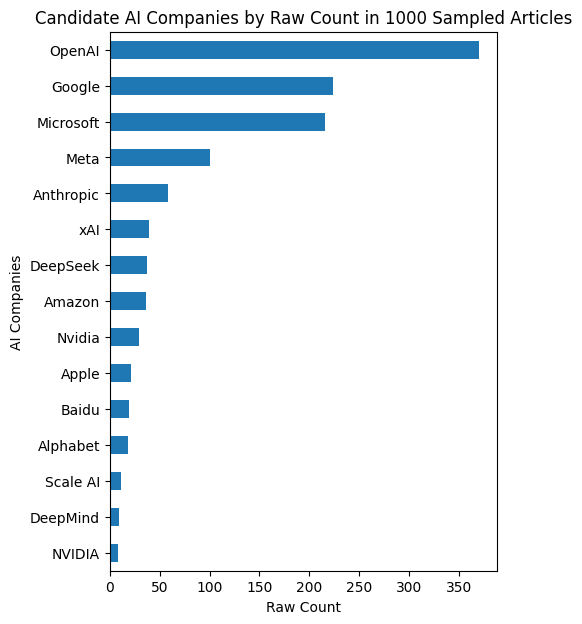

In [108]:
plot_df = comp_candidates.head(15).sort_values("raw_count")

plot_df.plot(
    x="entity_raw",
    y="raw_count",
    kind="barh",
    figsize=(5, 7),
    title="Candidate AI Companies by Raw Count in 1000 Sampled Articles",
    xlabel="Raw Count",
    ylabel="AI Companies",
    legend=False
)

In [103]:
comp_candidate_pairs = list(comp_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
comp_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in comp_candidate_pairs])
comp_candidate_pairs_str

'- (OpenAI, 370)\n- (Google, 224)\n- (Microsoft, 216)\n- (Meta, 100)\n- (Anthropic, 58)\n- (xAI, 39)\n- (DeepSeek, 37)\n- (Amazon, 36)\n- (Nvidia, 29)\n- (Apple, 21)\n- (Baidu, 19)\n- (Alphabet, 18)\n- (Scale AI, 11)\n- (DeepMind, 9)\n- (NVIDIA, 8)\n- (Alibaba, 8)\n- (Perplexity, 7)\n- (Tesla, 6)\n- (IBM, 6)\n- (Perplexity AI, 6)\n- (AMD, 5)\n- (Adobe, 5)\n- (Oracle, 5)\n- (X, 4)\n- (Taskade, 4)\n- (Stability AI, 4)\n- (Alphabet Inc., 4)\n- (Alibaba Cloud, 4)\n- (Zhipu AI, 4)\n- (Baichuan, 3)\n- (Character.AI, 3)\n- (Qualcomm, 3)\n- (Zoom, 3)\n- (LinkedIn, 3)\n- (Huawei, 3)\n- (Leena AI, 3)\n- (AWS, 3)\n- (Google DeepMind, 3)\n- (Google Cloud, 2)\n- (Jasper AI, 2)\n- (Intel, 2)\n- (Quora, 2)\n- (Mozilla, 2)\n- (Mistral, 2)\n- (Open AI, 2)\n- (SAP, 2)\n- (Hugging Face, 2)\n- (Canopy.us, 2)\n- (Accenture, 2)\n- (ByteDance, 2)\n- (Arm, 2)\n- (Broadcom, 2)\n- (Be My Eyes, 2)\n- (Deepseek, 2)\n- (ClickUp, 2)\n- (Cognigy, 2)\n- (Twitter, 2)\n- (Xiaomi, 2)\n- (Salesforce, 2)\n- (Runway, 2)\n-

In [109]:
org_top_system_msg = """\
You are a company name consolidation and ranking system for AI company mentions extracted from news articles.

The user will provide a list of (organization_name, mention_count).

Your tasks:

1. Merge raw names that clearly refer to the same company into one canonical company name.
2. Sum the counts of merged raw names.
3. Rank companies by total_count.
4. Return only the Top 15 AI companies.


Definition of AI company:
A company that primarily develops AI models, AI infrastructure, AI research, or AI platforms.

Major AI companies often appearing in news include:
OpenAI, Google, Microsoft, Meta, Anthropic, Nvidia, xAI, DeepSeek, Mistral, Cohere.


Do NOT include:
- media outlets
- publications
- venture funds
- consulting firms
- government agencies
- generic organizations
- unclear entities


Merging rules:

1. Merge case variations:
   Nvidia / NVIDIA

2. Merge brand variations:
   Alphabet → Google

3. Merge research labs into the parent company:
   DeepMind → Google

4. Do NOT merge different companies.

5. Be conservative when merging.

6. Ignore entities with extremely low counts unless clearly a major AI company.


Use counts exactly as provided.

Return valid JSON only.
"""

org_top_user_template = """\
Here is the list of (organization_name, mention_count) extracted from AI news:

{candidate_list}

Merge names that refer to the same company and sum their counts.

Return JSON in this exact format:

{{
  "ai_top15": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}

Rules:
- Use the counts exactly as given.
- Do not invent companies.
- Only include companies that appear in the list.
"""

org_top_json_schema = {
    "type": "object",
    "properties": {
        "ai_top15": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "integer"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["ai_top15"],
    "additionalProperties": False
}

In [110]:
import json
import pandas as pd
from jsonschema import validate, ValidationError

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

user_msg = org_top_user_template.format(
    candidate_list=comp_candidate_pairs_str
)

result_comp = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

try:
    validate(instance=result_comp, schema=org_top_json_schema)
    print("Schema validation passed.")
except ValidationError as e:
    print("Schema validation failed:")
    print(e)

result_comp

Schema validation passed.


{'ai_top15': [{'canonical_name': 'OpenAI',
   'total_count': 372,
   'source_raw_names': ['OpenAI', 'Open AI']},
  {'canonical_name': 'Google',
   'total_count': 250,
   'source_raw_names': ['Google',
    'Alphabet',
    'DeepMind',
    'Google DeepMind',
    'Alphabet Inc.']},
  {'canonical_name': 'Microsoft',
   'total_count': 216,
   'source_raw_names': ['Microsoft']},
  {'canonical_name': 'Meta', 'total_count': 100, 'source_raw_names': ['Meta']},
  {'canonical_name': 'Anthropic',
   'total_count': 58,
   'source_raw_names': ['Anthropic']},
  {'canonical_name': 'xAI', 'total_count': 39, 'source_raw_names': ['xAI']},
  {'canonical_name': 'DeepSeek',
   'total_count': 39,
   'source_raw_names': ['DeepSeek', 'Deepseek']},
  {'canonical_name': 'Amazon',
   'total_count': 36,
   'source_raw_names': ['Amazon']},
  {'canonical_name': 'Nvidia',
   'total_count': 37,
   'source_raw_names': ['Nvidia', 'NVIDIA']},
  {'canonical_name': 'Apple',
   'total_count': 21,
   'source_raw_names': ['App

In [111]:
ai_company_top = pd.DataFrame(result_comp["ai_top15"])

print("AI Top 10")
display(ai_company_top)

AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,372,"[OpenAI, Open AI]"
1,Google,250,"[Google, Alphabet, DeepMind, Google DeepMind, ..."
2,Microsoft,216,[Microsoft]
3,Meta,100,[Meta]
4,Anthropic,58,[Anthropic]
5,xAI,39,[xAI]
6,DeepSeek,39,"[DeepSeek, Deepseek]"
7,Amazon,36,[Amazon]
8,Nvidia,37,"[Nvidia, NVIDIA]"
9,Apple,21,[Apple]


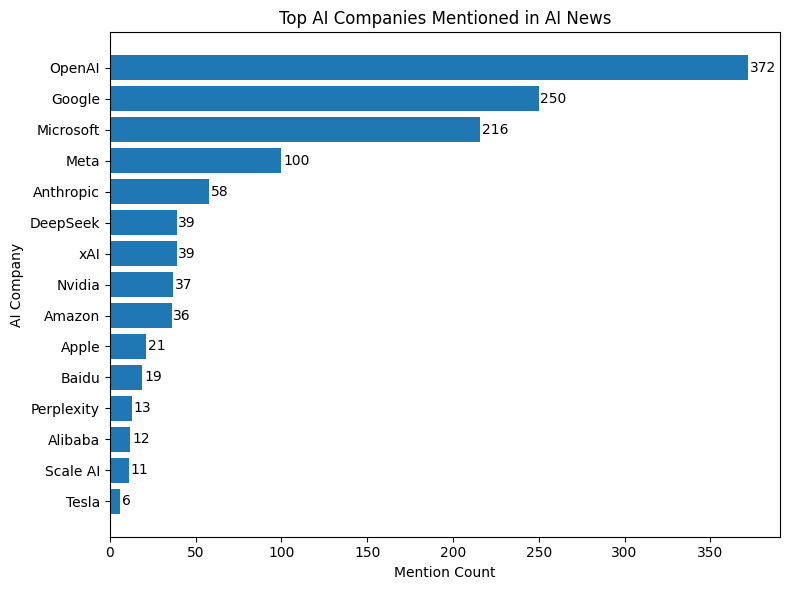

In [131]:
import matplotlib.pyplot as plt

plot_df = ai_company_top.sort_values("total_count", ascending=True)

plt.figure(figsize=(8, 6))
bars = plt.barh(plot_df["canonical_name"], plot_df["total_count"])

# add count labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.title("Top AI Companies Mentioned in AI News")
plt.xlabel("Mention Count")
plt.ylabel("AI Company")

plt.tight_layout()
plt.show()

##### ai_products

In [113]:
df_prod_long = (
    df_ai_ner[["chunk_uid", "ai_products"]]
    .explode("ai_products")
)

df_prod_long = df_prod_long[df_prod_long["ai_products"].notna()].copy()
df_prod_long["entity_raw"] = df_prod_long["ai_products"].astype(str).str.strip()
df_prod_long = df_prod_long[df_prod_long["entity_raw"] != ""]

prod_raw_counts = (
    df_prod_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(prod_raw_counts.shape)

prod_candidates = prod_raw_counts.loc[
    prod_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(prod_candidates.shape)
prod_candidates

(408, 2)
(115, 2)


,entity_raw,raw_count
0,ChatGPT,393
1,GPT-4,53
2,Bard,49
3,Gemini,39
4,Copilot,35
...,...,...
110,DALL-E 3,2
111,Codex,2
112,CoPilot,2
113,AlphaGo,2


In [114]:
prod_candidate_pairs = list(
    prod_candidates[["entity_raw", "raw_count"]]
    .itertuples(index=False, name=None)
)
prod_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in prod_candidate_pairs])
prod_candidate_pairs_str

'- (ChatGPT, 393)\n- (GPT-4, 53)\n- (Bard, 49)\n- (Gemini, 39)\n- (Copilot, 35)\n- (Bing, 30)\n- (Grok, 25)\n- (GPT-5, 18)\n- (DeepSeek, 18)\n- (Meta AI, 17)\n- (Claude, 16)\n- (GPT-4o, 15)\n- (GPT-3.5, 13)\n- (Alexa, 11)\n- (Llama, 10)\n- (ChatGPT Plus, 9)\n- (DALL-E, 9)\n- (Bing Chat, 9)\n- (Microsoft Copilot, 8)\n- (ClickUp Brain Chat Agents, 8)\n- (Replika, 8)\n- (Ernie Bot, 8)\n- (GPT, 8)\n- (R1, 8)\n- (Google Bard, 8)\n- (Dall-E, 7)\n- (GPT-3, 7)\n- (Gemini Advanced, 7)\n- (Bing AI, 7)\n- (LaMDA, 7)\n- (Llama 4, 6)\n- (Claude 3.5 Sonnet, 6)\n- (Gemini Ultra, 6)\n- (Comet, 6)\n- (Ernie, 5)\n- (ClickUp AI, 5)\n- (ClickUp Brain, 5)\n- (DeepSeek-R1, 5)\n- (Claude Code, 5)\n- (Gemini Pro, 5)\n- (Grok 4, 5)\n- (Claude 3.7 Sonnet, 5)\n- (Amazon Bedrock, 4)\n- (Grok Imagine, 4)\n- (Gemini AI, 4)\n- (Gemini 3, 4)\n- (Claude 3 Opus, 4)\n- (Copilot+, 4)\n- (DeepSeek R1, 4)\n- (Siri, 4)\n- (o1, 4)\n- (AI Overviews, 3)\n- (ChatGPT-5, 3)\n- (Copilot for Microsoft 365, 3)\n- (Duet AI, 3)\n- (Ba

In [115]:
prod_top_system_msg = """\
You are an AI product name consolidation and ranking system.

The user will provide a list of (product_name, mention_count) extracted from AI news.

Your tasks:

1. Merge raw names that clearly refer to the same AI product into one canonical product name.
2. Sum the counts of merged raw names.
3. Rank products by total_count.
4. Return only the Top 15 AI products.


Definition of AI product:
A specific AI system, assistant, model family, or AI platform released by a company.

Examples of AI products include:
ChatGPT, GPT-4, GPT-4o, Gemini, Claude, DeepSeek, Grok, Copilot, Midjourney, DALL-E, Sora, Llama.


Do NOT include:
- company names
- research labs
- generic technologies
- vague terms like "AI model", "chatbot", or "assistant"


Merging rules:

1. Merge case variations:
   ChatGPT / chatgpt

2. Merge naming variations:
   GPT4 / GPT-4

3. Merge model versions into the main product family when appropriate:
   GPT-4, GPT-4o → ChatGPT
   Claude 3 → Claude
   Gemini 1.5 → Gemini

4. Be conservative when merging.
5. Do NOT merge different products.

Use counts exactly as given.

Return valid JSON only.
"""

prod_top_user_template = """\
Here is the list of (product_name, mention_count) extracted from AI news:

{candidate_list}

Merge names that refer to the same AI product and sum their counts.

Return JSON in this exact format:

{{
  "ai_products_top15": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}

Rules:
- Use the counts exactly as given.
- Do not invent products.
- Only include products that appear in the list.
"""

prod_top_json_schema = {
    "type": "object",
    "properties": {
        "ai_products_top15": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "integer"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["ai_products_top15"],
    "additionalProperties": False
}

In [116]:
user_msg = prod_top_user_template.format(candidate_list=prod_candidate_pairs_str)
result_prod = generate_text(
    client=client,
    system_msg=prod_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_prod, schema=prod_top_json_schema)

In [117]:
ai_prod_top = pd.DataFrame(result_prod["ai_products_top15"])

print("AI Top 15")
display(ai_prod_top)

AI Top 15


,canonical_name,total_count,source_raw_names
0,ChatGPT,418,"[ChatGPT, GPT-4, GPT-5, GPT-4o, GPT-3.5, ChatG..."
1,Gemini,74,"[Gemini, Gemini Advanced, Gemini Ultra, Gemini..."
2,Copilot,56,"[Copilot, Microsoft Copilot, Copilot+, Copilot..."
3,Bing,46,"[Bing, Bing Chat, Bing AI, Bing Chat Enterprise]"
4,Claude,35,"[Claude, Claude 3.5 Sonnet, Claude Code, Claud..."
5,Grok,32,"[Grok, Grok 4, Grok Imagine, Grok 3]"
6,DeepSeek,29,"[DeepSeek, DeepSeek-R1, DeepSeek R1, DeepSeek-..."
7,Llama,24,"[Llama, Llama 4, Llama 2, Llama 3, Llama 3.1, ..."
8,Bard,60,"[Bard, Google Bard, Bard Advanced, Bard AI]"
9,Ernie Bot,15,"[Ernie Bot, Ernie, Ernie 4.0, ERNIE 5.0]"


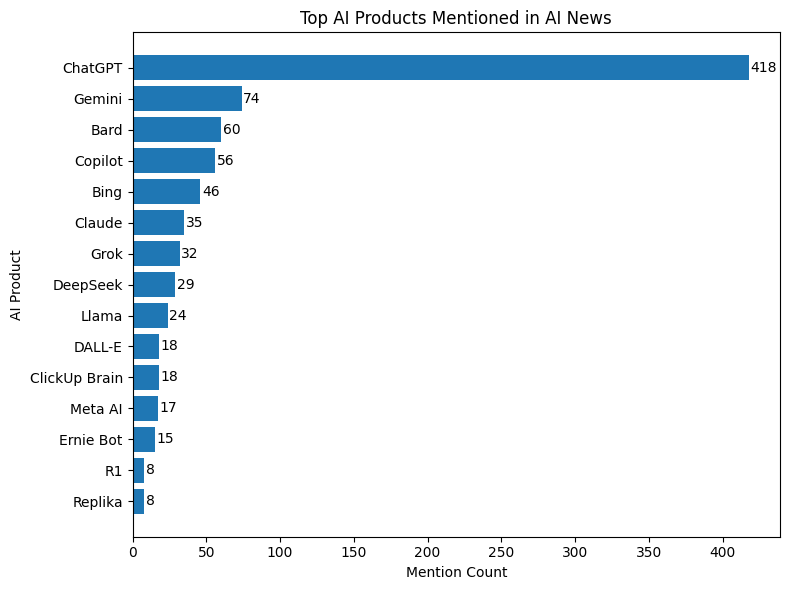

In [130]:
import matplotlib.pyplot as plt

plot_df = ai_prod_top.sort_values("total_count", ascending=True)

plt.figure(figsize=(8, 6))
bars = plt.barh(plot_df["canonical_name"], plot_df["total_count"])

# add count labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.title("Top AI Products Mentioned in AI News")
plt.xlabel("Mention Count")
plt.ylabel("AI Product")

plt.tight_layout()
plt.show()

#### ai_technologies and capabilities

In [121]:
df_tech_long = (
    df_ai_ner[["chunk_uid", "ai_technologies_and_capabilities"]]
    .explode("ai_technologies_and_capabilities")
)

df_tech_long = df_tech_long[df_tech_long["ai_technologies_and_capabilities"].notna()].copy()
df_tech_long["entity_raw"] = df_tech_long["ai_technologies_and_capabilities"].astype(str).str.strip()
df_tech_long = df_tech_long[df_tech_long["entity_raw"] != ""]

tech_raw_counts = (
    df_tech_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(tech_raw_counts.shape)

tech_candidates = tech_raw_counts.loc[
    tech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(tech_candidates.shape)
tech_candidates = tech_candidates[~tech_candidates['entity_raw'].isin(['artificial intelligence', 'AI', 'technology', 'data', 'machine', 'platform'])]
tech_candidates

(640, 2)
(138, 2)


,entity_raw,raw_count
0,generative AI,180
2,large language models,61
3,reasoning,37
5,machine learning,28
6,large language model,25
...,...,...
133,foundation model,2
134,artificial intelligence chatbot,2
135,voice commands,2
136,voice recognition,2


In [125]:
tech_candidate_pairs = list(
    tech_candidates[["entity_raw", "raw_count"]]
    .itertuples(index=False, name=None)
)
tech_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in tech_candidate_pairs])
tech_candidate_pairs_str

'- (generative AI, 180)\n- (large language models, 61)\n- (reasoning, 37)\n- (machine learning, 28)\n- (large language model, 25)\n- (image generation, 23)\n- (coding, 18)\n- (AI models, 18)\n- (AI chatbot, 17)\n- (conversational AI, 17)\n- (natural language processing, 15)\n- (AI agents, 15)\n- (artificial general intelligence, 14)\n- (AI Agents, 13)\n- (multimodal AI, 13)\n- (agentic AI, 12)\n- (AI chips, 11)\n- (foundation models, 10)\n- (AI training, 9)\n- (AI model, 9)\n- (AI chatbots, 9)\n- (open-source, 9)\n- (AGI, 8)\n- (AI agent, 8)\n- (chatbots, 8)\n- (generative artificial intelligence, 8)\n- (chatbot, 7)\n- (language model, 7)\n- (fine-tuning, 7)\n- (inference, 7)\n- (LLMs, 7)\n- (AI assistant, 7)\n- (language models, 7)\n- (reinforcement learning, 7)\n- (model training, 6)\n- (deep learning, 6)\n- (training, 6)\n- (LLM, 5)\n- (predictive analytics, 5)\n- (AI search, 5)\n- (multimodal, 5)\n- (video generation, 5)\n- (AI-powered search, 4)\n- (Artificial Intelligence, 4)\n- 

In [122]:
tech_top_system_msg = """\
You are an AI technology and capability name consolidation and ranking system.

The user will provide a list of (technology_or_capability_name, mention_count) extracted from AI news.

Your tasks:

1. Merge raw names that clearly refer to the same AI technology or capability into one canonical name.
2. Sum the counts of merged raw names.
3. Rank items by total_count.
4. Return only the Top 15 AI technologies_and_capabilities.


Definition:
An AI technology_or_capability is a specific AI model type, technical approach, system capability, or core technical function.

Examples include:
- generative AI
- large language models
- multimodal AI
- reasoning
- image generation
- video generation
- coding assistance
- fine-tuning
- inference
- retrieval-augmented generation
- reinforcement learning
- AI chips
- agentic AI
- speech recognition
- model training


Do NOT include:
- company names
- product names
- research labs
- vague umbrella terms
- business outcomes
- market narratives
- corporate actions


Do NOT keep overly broad or low-information terms such as:
- AI
- artificial intelligence
- technology
- software
- data
- data intelligence
- innovation
- automation
- platform
- digital transformation


Merging rules:

1. Merge case variations:
   - LLM / llm
   - RAG / rag

2. Merge obvious naming variations:
   - large language model / large language models
   - retrieval augmented generation / retrieval-augmented generation
   - multimodal model / multimodal AI
   - image generator / image generation

3. Prefer the more standard and informative canonical name when merging.
   For example:
   - use "large language models" instead of "LLMs" if both appear
   - use "retrieval-augmented generation" instead of "RAG" if both appear

4. When a broad term and a more specific term both appear, keep the more specific one.
   For example:
   - keep "large language models" rather than "AI"
   - keep "image generation" rather than "technology"

5. Do NOT merge different technologies or capabilities.

6. Be conservative when merging.

Use counts exactly as given.

Return valid JSON only.
"""

In [123]:
tech_top_user_template = """\
Here is the list of (technology_or_capability_name, mention_count) extracted from AI news:

{candidate_list}

Merge names that refer to the same AI technology or capability and sum their counts.

Return JSON in this exact format:

{{
  "ai_technologies_and_capabilities_top15": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}

Rules:
- Use the counts exactly as given.
- Do not invent items.
- Only include technologies or capabilities that appear in the list.
"""

tech_top_json_schema = {
    "type": "object",
    "properties": {
        "ai_technologies_and_capabilities_top15": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "integer"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["ai_technologies_and_capabilities_top15"],
    "additionalProperties": False
}

In [126]:
user_msg = tech_top_user_template.format(
    candidate_list=tech_candidate_pairs_str
)

result_tech = generate_text(
    client=client,
    system_msg=tech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_tech, schema=tech_top_json_schema)

In [127]:
ai_tech_top = pd.DataFrame(result_tech["ai_technologies_and_capabilities_top15"])
ai_tech_top

,canonical_name,total_count,source_raw_names
0,generative AI,190,"[generative AI, generative artificial intellig..."
1,large language models,104,"[large language models, large language model, ..."
2,reasoning,42,"[reasoning, logical reasoning, logic]"
3,machine learning,34,"[machine learning, machine-learning systems, m..."
4,image generation,28,"[image generation, image generator, AI image g..."
5,coding,26,"[coding, coding assistance, code generation]"
6,AI agents,38,"[AI agents, AI Agents, AI agent, agentic AI, a..."
7,multimodal AI,24,"[multimodal AI, multimodal, multimodal capabil..."
8,conversational AI,20,"[conversational AI, Conversational AI]"
9,AI chatbots,41,"[AI chatbot, AI chatbots, chatbots, chatbot, A..."


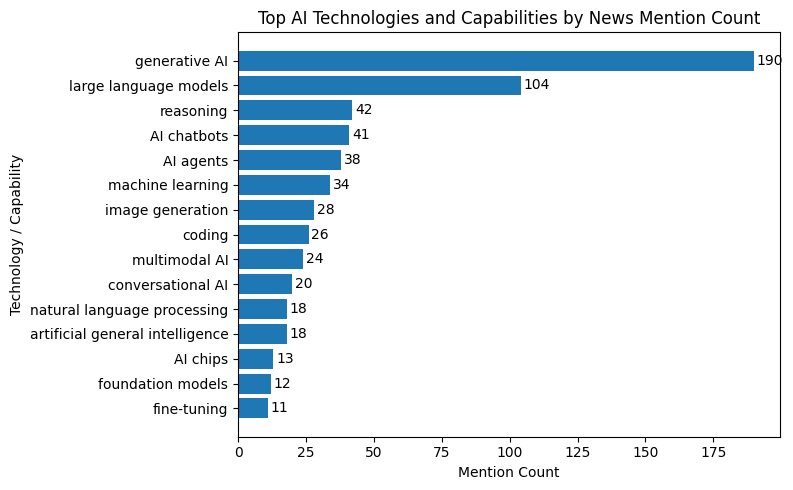

In [129]:
import matplotlib.pyplot as plt

plot_df = (
    ai_tech_top
    .sort_values("total_count", ascending=False)
    .sort_values("total_count", ascending=True)
)

plt.figure(figsize=(8, 5))
bars = plt.barh(plot_df["canonical_name"], plot_df["total_count"])

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.title("Top AI Technologies and Capabilities by News Mention Count")
plt.xlabel("Mention Count")
plt.ylabel("Technology / Capability")

plt.tight_layout()
plt.show()